In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Import libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, GlobalAveragePooling1D,
    Dense, Dropout, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print('TensorFlow version:', tf.__version__)
print('NumPy version:', np.__version__)
print('All libraries imported successfully.')

TensorFlow version: 2.20.0
NumPy version: 2.0.2
All libraries imported successfully.


In [3]:
DATASET_PATH = '/content/drive/MyDrive/ColabData/FYDP/T-ITS_Preprocesses-dataset.csv'
df = pd.read_csv(DATASET_PATH)
CLASS_NAMES = {0: 'Benign', 1: 'DoS', 2: 'EvilTwin', 3: 'FDI', 4: 'Replay'}
print('Dataset loaded successfully.')
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Features: {df.shape[1] - 1}')
print('\nClass distribution:')
for cls, name in CLASS_NAMES.items():
    count = (df['class'] == cls).sum()
    pct = count / len(df) * 100
    print(f'  {cls} ({name}): {count} samples ({pct:.1f}%)')

Dataset loaded successfully.
Shape: 54783 rows x 38 columns
Features: 37

Class distribution:
  0 (Benign): 13716 samples (25.0%)
  1 (DoS): 12646 samples (23.1%)
  2 (EvilTwin): 12981 samples (23.7%)
  3 (FDI): 11158 samples (20.4%)
  4 (Replay): 4282 samples (7.8%)


In [4]:
X = df.drop(columns=['class']).values.astype(np.float32)
y = df['class'].values.astype(np.int32)

NUM_CLASSES  = 5
NUM_FEATURES = X.shape[1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f'Total samples     : {len(X)}')
print(f'Training samples  : {len(X_train)} (70%)')
print(f'Testing samples   : {len(X_test)} (30%)')
print(f'Number of features: {NUM_FEATURES}')
print(f'Number of classes : {NUM_CLASSES}')

print('\nTrain class distribution:')
for cls in range(NUM_CLASSES):
    count = np.sum(y_train == cls)
    print(f'  {cls} ({CLASS_NAMES[cls]}): {count}')

print('\nTest class distribution:')
for cls in range(NUM_CLASSES):
    count = np.sum(y_test == cls)
    print(f'  {cls} ({CLASS_NAMES[cls]}): {count}')

Total samples     : 54783
Training samples  : 38348 (70%)
Testing samples   : 16435 (30%)
Number of features: 37
Number of classes : 5

Train class distribution:
  0 (Benign): 9601
  1 (DoS): 8852
  2 (EvilTwin): 9087
  3 (FDI): 7811
  4 (Replay): 2997

Test class distribution:
  0 (Benign): 4115
  1 (DoS): 3794
  2 (EvilTwin): 3894
  3 (FDI): 3347
  4 (Replay): 1285


In [5]:
# StandardScaler is required for 1D-CNN because convolutional filters are
# sensitive to feature magnitude. Features in this dataset span very different
# numerical ranges (e.g., tcp.seq_raw in millions vs ip.hdr_len around 20).
# Scaler is fit ONLY on training data to prevent data leakage from the test set.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('StandardScaler applied.')
print(f'Train mean (first 5 features): {X_train_scaled[:, :5].mean(axis=0).round(4)}')
print(f'Train std  (first 5 features): {X_train_scaled[:, :5].std(axis=0).round(4)}')

StandardScaler applied.
Train mean (first 5 features): [-0.  0.  0.  0.  0.]
Train std  (first 5 features): [1.     1.     1.     1.0001 1.    ]


In [6]:
# 1D-CNN expects input shape: (samples, timesteps, channels)
# Each row of 37 scaled features is treated as a 1D sequence
# of length 37 with 1 channel
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], NUM_FEATURES, 1)
X_test_cnn  = X_test_scaled.reshape(X_test_scaled.shape[0],  NUM_FEATURES, 1)

print(f'X_train shape after reshape: {X_train_cnn.shape}')
print(f'X_test  shape after reshape: {X_test_cnn.shape}')
print('Input shape for 1D-CNN: (samples, 37 features, 1 channel)')

X_train shape after reshape: (38348, 37, 1)
X_test  shape after reshape: (16435, 37, 1)
Input shape for 1D-CNN: (samples, 37 features, 1 channel)


In [7]:
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=y_train
)
class_weight_dict = {i: class_weights_array[i] for i in range(NUM_CLASSES)}

print('Computed class weights (balanced):')
for cls, weight in class_weight_dict.items():
    print(f'  Class {cls} ({CLASS_NAMES[cls]}): {weight:.4f}')

Computed class weights (balanced):
  Class 0 (Benign): 0.7988
  Class 1 (DoS): 0.8664
  Class 2 (EvilTwin): 0.8440
  Class 3 (FDI): 0.9819
  Class 4 (Replay): 2.5591


In [8]:
def build_lightweight_1dcnn(input_length, num_classes):
    model = Sequential([
        # Convolutional Block 1
        # kernel_size=5 scans 5 consecutive features per step
        Conv1D(filters=64, kernel_size=5, activation='relu',
               padding='same', input_shape=(input_length, 1)),
        BatchNormalization(),

        # Convolutional Block 2
        Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),

        # GlobalAveragePooling averages each filter map into one value.
        # Chosen over MaxPooling1D+Flatten because with only 37 features,
        # repeated MaxPooling compresses too aggressively and causes
        # information loss that leads to class collapse.
        GlobalAveragePooling1D(),

        # Classifier Head
        Dense(64, activation='relu'),
        Dropout(0.3),

        # Output Layer
        Dense(num_classes, activation='softmax')
    ], name='Lightweight_1DCNN_IDS')

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


model = build_lightweight_1dcnn(NUM_FEATURES, NUM_CLASSES)
model.summary()

Model: "Lightweight_1DCNN_IDS"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 37, 64)         │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 37, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 37, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 37, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,437 (134.52 KB)

 Trainable params: 34,053 (133.02 KB)

 Non-trainable params: 384 (1.50 KB)

In [9]:
total_params         = model.count_params()
trainable_params     = sum([tf.size(w).numpy() for w in model.trainable_weights])
non_trainable_params = total_params - trainable_params
memory_kb            = (total_params * 4) / 1024

print('=' * 47)
print('   Lightweight Model Parameter Analysis')
print('=' * 47)
print(f'  Total Parameters       : {total_params:,}')
print(f'  Trainable Parameters   : {trainable_params:,}')
print(f'  Non-Trainable Params   : {non_trainable_params:,}')
print(f'  Model Size (float32)   : {memory_kb:.2f} KB')
print('=' * 47)
print(f'\n  Lightweight Verdict:')
if total_params < 100_000:
    print(f'  Model is lightweight (<100K params) - Suitable for UAV edge deployment.')
else:
    print(f'  Model exceeds 100K params - consider reducing filters.')

   Lightweight Model Parameter Analysis
  Total Parameters       : 34,437
  Trainable Parameters   : 34,053
  Non-Trainable Params   : 384
  Model Size (float32)   : 134.52 KB

  Lightweight Verdict:
  Model is lightweight (<100K params) - Suitable for UAV edge deployment.


In [10]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-5,
    verbose=1
)

history = model.fit(
    X_train_cnn, y_train,
    epochs=100,
    batch_size=256,
    validation_split=0.15,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print('\nTraining complete.')
print(f'Stopped at epoch: {len(history.history["loss"])}')

Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 13s 67ms/step - accuracy: 0.7278 - loss: 0.5929 - val_accuracy: 0.0824 - val_loss: 2.0795 - learning_rate: 0.0010
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 10s 77ms/step - accuracy: 0.8802 - loss: 0.2632 - val_accuracy: 0.2706 - val_loss: 2.3659 - learning_rate: 0.0010
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 11s 89ms/step - accuracy: 0.9412 - loss: 0.1407 - val_accuracy: 0.5116 - val_loss: 1.8059 - learning_rate: 0.0010
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 25s 126ms/step - accuracy: 0.9620 - loss: 0.0923 - val_accuracy: 0.6906 - val_loss: 0.7500 - learning_rate: 0.0010
Epoch 5/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 16s 89ms/step - accuracy: 0.9749 - loss: 0.0650 - val_accuracy: 0.9414 - val_loss: 0.1480 - learning_rate: 0.0010
Epoch 6/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 12s 90ms/step - accuracy: 0.9798 - loss: 0.0513 - val_accuracy: 0.9868 - val_loss: 0.0414 - learning_rate: 0.0010
Epoch 7/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 17s 131ms/step - accuracy: 0

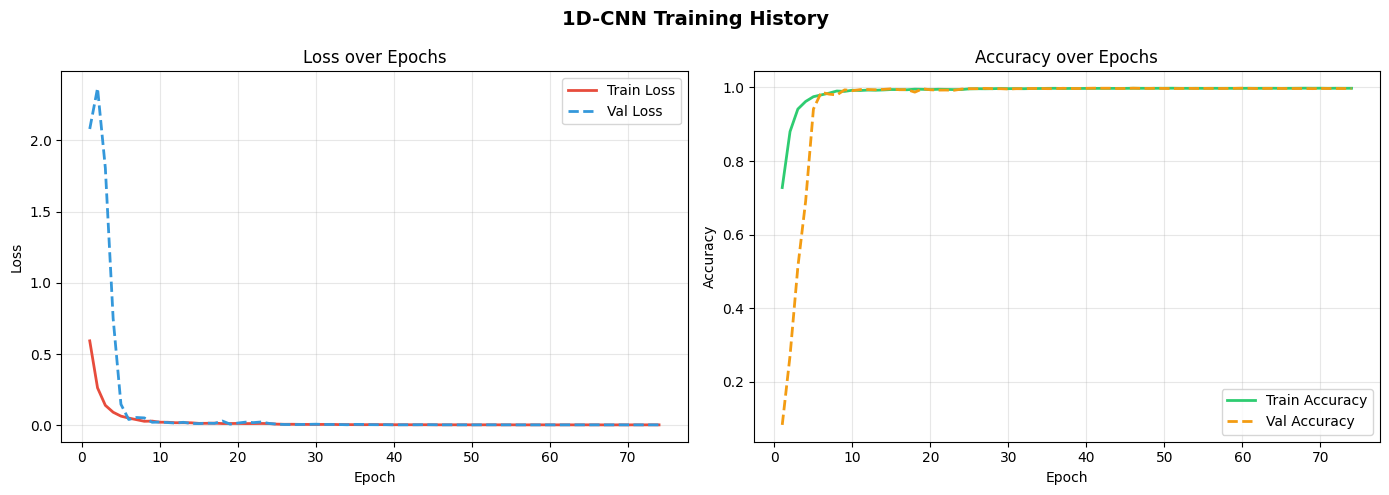

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('1D-CNN Training History', fontsize=14, fontweight='bold')

epochs_range = range(1, len(history.history['loss']) + 1)

# Loss
axes[0].plot(epochs_range, history.history['loss'],
             label='Train Loss', color='#e74c3c', linewidth=2)
axes[0].plot(epochs_range, history.history['val_loss'],
             label='Val Loss', color='#3498db', linewidth=2, linestyle='--')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, history.history['accuracy'],
             label='Train Accuracy', color='#2ecc71', linewidth=2)
axes[1].plot(epochs_range, history.history['val_accuracy'],
             label='Val Accuracy', color='#f39c12', linewidth=2, linestyle='--')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/1dcnn_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
y_pred_probs = model.predict(X_test_cnn, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print('=' * 50)
print('   Overall Evaluation Metrics (Test Set)')
print('=' * 50)
print(f'  Accuracy  : {accuracy  * 100:.2f}%')
print(f'  Precision : {precision * 100:.2f}%')
print(f'  Recall    : {recall    * 100:.2f}%')
print(f'  F1-Score  : {f1        * 100:.2f}%')
print('=' * 50)

target_names = [CLASS_NAMES[i] for i in range(NUM_CLASSES)]
print('\nPer-Class Classification Report:')
print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))

   Overall Evaluation Metrics (Test Set)
  Accuracy  : 99.59%
  Precision : 99.59%
  Recall    : 99.59%
  F1-Score  : 99.59%

Per-Class Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      4115
         DoS       0.99      0.99      0.99      3794
    EvilTwin       0.99      0.99      0.99      3894
         FDI       1.00      1.00      1.00      3347
      Replay       1.00      1.00      1.00      1285

    accuracy                           1.00     16435
   macro avg       1.00      1.00      1.00     16435
weighted avg       1.00      1.00      1.00     16435



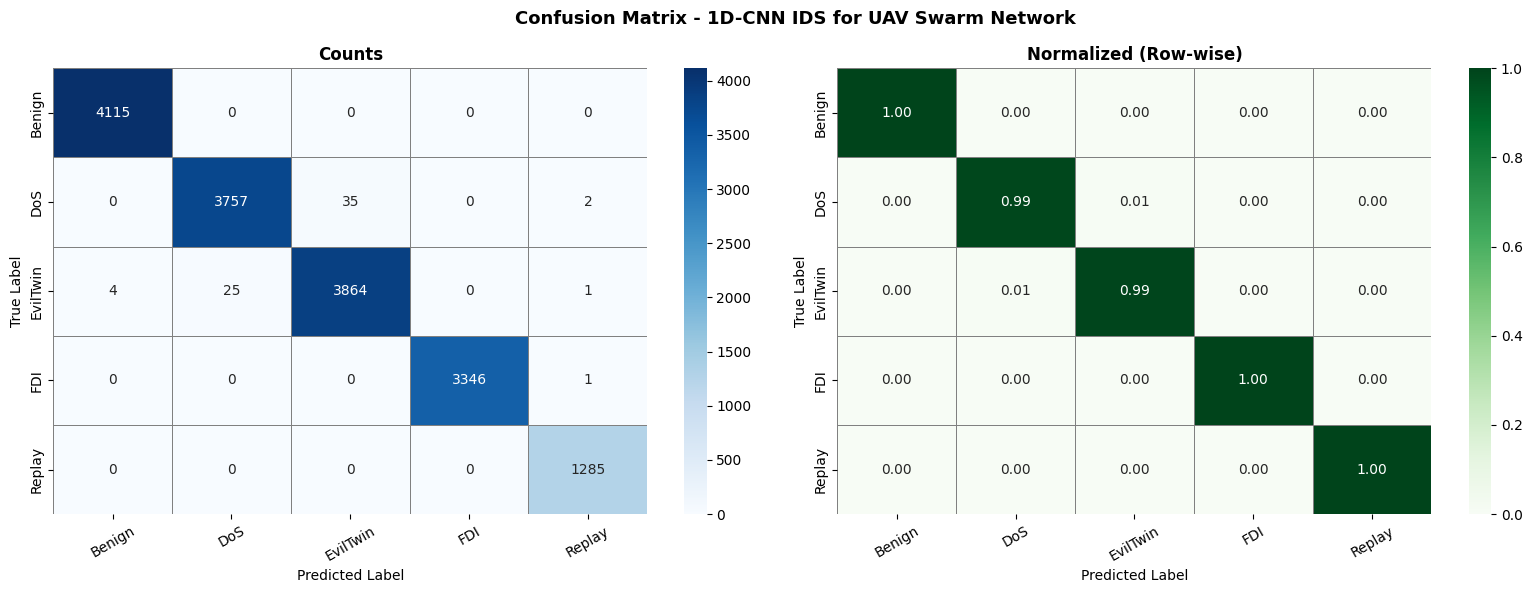

In [13]:
cm            = confusion_matrix(y_test, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)
target_names  = [CLASS_NAMES[i] for i in range(NUM_CLASSES)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Confusion Matrix - 1D-CNN IDS for UAV Swarm Network',
             fontsize=13, fontweight='bold')

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=target_names, yticklabels=target_names,
            linewidths=0.5, linecolor='gray')
axes[0].set_title('Counts', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].tick_params(axis='x', rotation=30)

# Normalized
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Greens', ax=axes[1],
            xticklabels=target_names, yticklabels=target_names,
            linewidths=0.5, linecolor='gray', vmin=0, vmax=1)
axes[1].set_title('Normalized (Row-wise)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/1dcnn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

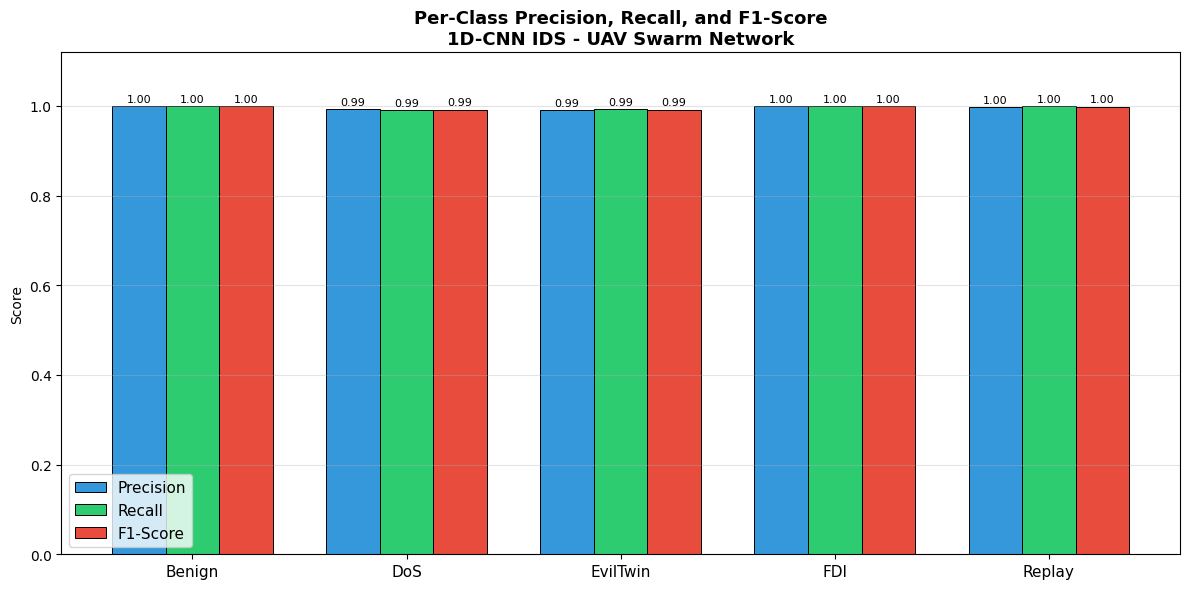

In [14]:
per_class_precision = precision_score(y_test, y_pred, average=None, zero_division=0)
per_class_recall    = recall_score(y_test, y_pred, average=None, zero_division=0)
per_class_f1        = f1_score(y_test, y_pred, average=None, zero_division=0)

target_names = [CLASS_NAMES[i] for i in range(NUM_CLASSES)]
x     = np.arange(NUM_CLASSES)
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width, per_class_precision, width, label='Precision',
               color='#3498db', edgecolor='black', linewidth=0.7)
bars2 = ax.bar(x,          per_class_recall,    width, label='Recall',
               color='#2ecc71', edgecolor='black', linewidth=0.7)
bars3 = ax.bar(x + width,  per_class_f1,        width, label='F1-Score',
               color='#e74c3c', edgecolor='black', linewidth=0.7)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                f'{h:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_title('Per-Class Precision, Recall, and F1-Score\n1D-CNN IDS - UAV Swarm Network',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(target_names, fontsize=11)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.35)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/1dcnn_per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
MODEL_SAVE_PATH = '/content/drive/MyDrive/1dcnn_ids_uav_model.h5'
model.save(MODEL_SAVE_PATH)
print(f'Model saved to: {MODEL_SAVE_PATH}')

print('\n' + '=' * 50)
print('   Final Summary')
print('=' * 50)
print(f'  Model         : Lightweight 1D-CNN IDS')
print(f'  Architecture  : Conv1D(64) -> Conv1D(128) -> GAP -> Dense(64) -> Dense(5)')
print(f'  Total Params  : {model.count_params():,}')
print(f'  Model Size    : {(model.count_params() * 4) / 1024:.2f} KB')
print(f'  Train Samples : {len(X_train)}')
print(f'  Test Samples  : {len(X_test)}')
print(f'  Accuracy      : {accuracy  * 100:.2f}%')
print(f'  Precision     : {precision * 100:.2f}%')
print(f'  Recall        : {recall    * 100:.2f}%')
print(f'  F1-Score      : {f1        * 100:.2f}%')
print('=' * 50)

Model saved to: /content/drive/MyDrive/1dcnn_ids_uav_model.h5

   Final Summary
  Model         : Lightweight 1D-CNN IDS
  Architecture  : Conv1D(64) -> Conv1D(128) -> GAP -> Dense(64) -> Dense(5)
  Total Params  : 34,437
  Model Size    : 134.52 KB
  Train Samples : 38348
  Test Samples  : 16435
  Accuracy      : 99.59%
  Precision     : 99.59%
  Recall        : 99.59%
  F1-Score      : 99.59%


In [16]:
total_params = model.count_params()
size_kb = (total_params * 4) / 1024

print(f"Total Parameters : {total_params:,}")
print(f"Model Size (KB)  : {size_kb:.2f} KB")
print(f"Model Size (MB)  : {size_kb/1024:.3f} MB")

if total_params < 100_000:
    print("Verdict:  Lightweight — suitable for UAV edge deployment.")
elif total_params < 500_000:
    print("Verdict:  Compact — acceptable for edge with quantization.")
else:
    print("Verdict:  Heavy — consider pruning or quantization.")

Total Parameters : 34,437
Model Size (KB)  : 134.52 KB
Model Size (MB)  : 0.131 MB
Verdict:  Lightweight — suitable for UAV edge deployment.


In [17]:
import time
import numpy as np

_ = model.predict(X_test_cnn[:10], verbose=0)

# Batch prediction time
t0 = time.perf_counter()
model.predict(X_test_cnn, batch_size=256, verbose=0)
t1 = time.perf_counter()

total_ms     = (t1 - t0) * 1000
per_sample_ms = total_ms / len(X_test_cnn)

print(f"Total prediction time  : {total_ms:.2f} ms")
print(f"Per-sample latency     : {per_sample_ms:.4f} ms")
print(f"Throughput             : {len(X_test_cnn) / (t1 - t0):,.0f} samples/sec")

Total prediction time  : 1644.26 ms
Per-sample latency     : 0.1000 ms
Throughput             : 9,995 samples/sec
